# Apollo Hospitals: Appointment No-Show and Patient Engagement Analysis

**Milestone Project 4**  
**Prepared by: Shivji**  
**Tools: Python, Pandas, NumPy, Matplotlib and Seaborn**

## Project Background

Apollo Hospitals provides in-clinic consultations, video
consultations and home visits across 15 cities in India.
Patients book through the Apollo App, website, call centre,
walk-in and partner apps.

Missed appointments affect doctor utilisation, potential
revenue and continuity of patient care. This project explores
appointment patterns, patient engagement, financial performance
and service quality to identify opportunities for improvement.

## Project Objective

Use Exploratory Data Analysis to identify factors associated
with no-shows, compare patient attendance across segments,
assess reminder patterns and provide practical recommendations.

## About the Dataset

- Appointment dataset: 75,000 rows and 52 columns.
  Each row represents one appointment.
- Doctor dataset: 320 rows and 15 columns.
  Each row represents one doctor.
- Appointment dates span 2022–2024.
- The datasets are joined using doctor_id.

## Analysis Areas

- Business Overview
- No-Show Analysis
- Reminder and Engagement Effectiveness
- Patient and Demographic Segmentation
- Financial Performance
- Doctor Utilisation and Service Quality

## Analysis Rules

- No-show rate = No-Show appointments divided by the total
  of Completed, No-Show and Cancelled appointments.
  Scheduled appointments are excluded.
- Realized revenue analysis uses Completed appointments only.
- Waiting time, consultation duration, satisfaction and
  utilisation analysis uses Completed appointments only.
- The literal value "None" means not applicable in chronic
  condition, membership type, insurance provider and
  cancellation reason; it is not treated as missing.
- Potential revenue at risk from no-shows is estimated
  separately using listed consultation fees.
- Findings describe associations and do not establish causation.

## Project Workflow

Data Loading → Data Validation and Preparation →
Exploratory Analysis → Visualisation →
Insights and Recommendations

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
appointments = pd.read_csv(
    "apollo_appointments_fact.csv",
    keep_default_na=False,
    na_values=[""]
)

doctors = pd.read_csv(
    "apollo_doctors_dim.csv",
    keep_default_na=False,
    na_values=[""]
)

print("Appointments:", appointments.shape)
print("Doctors:", doctors.shape)

Appointments: (75000, 52)
Doctors: (320, 15)


In [3]:
appointments.head()

,appointment_id,patient_id,doctor_id,appointment_date,appointment_day,appointment_day_of_week,appointment_month,appointment_quarter,appointment_year,appointment_hour,appointment_minute,time_slot,time_of_day,booking_date,booking_lead_days,booking_channel,appointment_type,specialty,city,state,hospital_name,patient_age,age_group,patient_gender,patient_city_tier,patient_chronic_condition,apollo_member,membership_type,reminder_type,reminders_sent,patient_prior_visits,patient_prior_no_shows,is_first_visit,repeat_visit,visit_reason,appointment_status,no_show,no_show_flag,cancellation_reason,consultation_fee,discount_pct,actual_fee_charged,insurance_coverage,insurance_provider,insurance_covered_amount,patient_out_of_pocket,revenue_realized,payment_mode,wait_time_minutes,consultation_duration_min,patient_satisfaction_score,doctor_utilization_pct
0,APPT5000001,PAT117608,DOC1035,2023-11-15,Wednesday,2,11,Q4,2023,15,30,15:30,Afternoon,2023-11-14,1,Apollo App,In-Clinic,Cardiology,Bengaluru,Karnataka,Apollo Clinic Jayanagar,76,Senior (60+),Female,1,None,No,None,SMS + WhatsApp,2,1,0,0,Yes,Joint Pain,Completed,No,0,None,2700,0,2700,No,None,0,2700,2700,UPI,11.0,40.0,4.8,84.2
1,APPT5000002,PAT128732,DOC1049,2023-03-13,Monday,0,3,Q1,2023,9,0,09:00,Morning,2023-03-05,8,Website,In-Clinic,Paediatrics,Pune,Maharashtra,Apollo Spectra Pune,6,Child (0-12),Male,1,None,No,None,SMS Only,1,1,0,0,Yes,Fever & Infection,Completed,No,0,None,1400,0,1400,No,None,0,1400,1400,UPI,21.0,18.0,4.1,64.5
2,APPT5000003,PAT137532,DOC1033,2022-02-07,Monday,0,2,Q1,2022,17,0,17:00,Evening,2022-02-07,0,Walk-In,In-Clinic,General Physician,Bengaluru,Karnataka,Apollo Spectra Koramangala,69,Senior (60+),Male,1,Hypothyroidism,No,None,SMS + WhatsApp + Call,3,1,0,0,Yes,Routine Checkup,Completed,No,0,None,600,0,600,No,None,0,600,600,Net Banking,6.0,6.0,5.0,75.6
3,APPT5000004,PAT113284,DOC1288,2023-11-20,Monday,0,11,Q4,2023,17,15,17:15,Evening,2023-11-20,0,Walk-In,In-Clinic,Dermatology,Delhi,Delhi,Apollo Hospital Sarita Vihar,47,Middle-aged (46-60),Female,1,Hypertension,No,None,SMS + WhatsApp + Call,3,1,0,0,Yes,Eye Care,Completed,No,0,None,1275,0,1275,No,None,0,1275,1275,UPI,2.0,25.0,4.4,68.6
4,APPT5000005,PAT107443,DOC1064,2024-02-02,Friday,4,2,Q1,2024,19,30,19:30,Evening,2024-02-01,1,Apollo App,In-Clinic,Gastroenterology,Coimbatore,Tamil Nadu,Apollo Clinic Coimbatore,45,Adult (31-45),Female,2,Hypertension,Yes,Apollo Silver,SMS + WhatsApp,2,1,0,0,Yes,Respiratory Issue,Completed,No,0,None,2000,15,1700,No,None,0,1700,1700,Cash,7.0,13.0,3.5,67.7


In [4]:
doctors.head()

,doctor_id,doctor_name,specialty,qualification,experience_years,city,state,hospital_name,consultation_fee,rating,total_reviews,available_days,avg_slot_duration_min,accepts_insurance,teleconsult_enabled
0,DOC1001,Dr. Deepa Sharma,Urology,"MBBS, MCh",12,Bengaluru,Karnataka,Apollo Hospital Bannerghatta,2300,4.4,1502,Mon-Fri,15,Yes,No
1,DOC1002,Dr. Venkatesan Khan,Paediatrics,"MBBS, MS, FRCS",25,Chandigarh,Punjab,Apollo Clinic Sector 8,1200,4.5,2453,Mon-Sat,10,Yes,Yes
2,DOC1003,Dr. Pradeep Menon,General Physician,"MBBS, DM",13,Mumbai,Maharashtra,Apollo Clinic Andheri,700,4.7,995,Mon-Wed-Fri-Sat,15,No,No
3,DOC1004,Dr. Vivek Mathew,General Physician,"MBBS, MD",31,Mumbai,Maharashtra,Apollo Hospital Navi Mumbai,1000,4.9,666,Mon-Wed-Fri-Sat,20,Yes,Yes
4,DOC1005,Dr. Savita Philip,General Physician,"MBBS, MD, PhD",5,Mumbai,Maharashtra,Apollo Hospital Navi Mumbai,600,4.5,1383,Mon-Sat,30,Yes,Yes


In [5]:
appointments.info()

<class 'pandas.DataFrame'>
RangeIndex: 75000 entries, 0 to 74999
Data columns (total 52 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   appointment_id              75000 non-null  str    
 1   patient_id                  75000 non-null  str    
 2   doctor_id                   75000 non-null  str    
 3   appointment_date            75000 non-null  str    
 4   appointment_day             75000 non-null  str    
 5   appointment_day_of_week     75000 non-null  int64  
 6   appointment_month           75000 non-null  int64  
 7   appointment_quarter         75000 non-null  str    
 8   appointment_year            75000 non-null  int64  
 9   appointment_hour            75000 non-null  int64  
 10  appointment_minute          75000 non-null  int64  
 11  time_slot                   75000 non-null  str    
 12  time_of_day                 75000 non-null  str    
 13  booking_date                75000 non-null

In [6]:
doctors.info()

<class 'pandas.DataFrame'>
RangeIndex: 320 entries, 0 to 319
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   doctor_id              320 non-null    str    
 1   doctor_name            320 non-null    str    
 2   specialty              320 non-null    str    
 3   qualification          320 non-null    str    
 4   experience_years       320 non-null    int64  
 5   city                   320 non-null    str    
 6   state                  320 non-null    str    
 7   hospital_name          320 non-null    str    
 8   consultation_fee       320 non-null    int64  
 9   rating                 320 non-null    float64
 10  total_reviews          320 non-null    int64  
 11  available_days         320 non-null    str    
 12  avg_slot_duration_min  320 non-null    int64  
 13  accepts_insurance      320 non-null    str    
 14  teleconsult_enabled    320 non-null    str    
dtypes: float64(1), in

In [7]:
missing = appointments.isna().sum()
print(missing[missing > 0])

wait_time_minutes             19725
consultation_duration_min     19725
patient_satisfaction_score    19725
doctor_utilization_pct        19725
dtype: int64


In [8]:
print("Missing values in doctors:", doctors.isna().sum().sum())

Missing values in doctors: 0


In [9]:
print("Duplicate appointment rows:", appointments.duplicated().sum())
print("Duplicate doctor rows:", doctors.duplicated().sum())

print("Duplicate appointment IDs:",
      appointments["appointment_id"].duplicated().sum())

print("Duplicate doctor IDs:",
      doctors["doctor_id"].duplicated().sum())

Duplicate appointment rows: 0
Duplicate doctor rows: 0
Duplicate appointment IDs: 0
Duplicate doctor IDs: 0


In [10]:
quality_columns = [
    column for column in appointments.columns
    if column.startswith((
        "wait_time",
        "consultation_duration",
        "patient_satisfaction",
        "doctor_util"
    ))
]

print("Quality columns:", quality_columns)

print("\nMissing quality values by status:")
display(
    appointments.groupby("appointment_status")[quality_columns]
    .agg(lambda column: column.isna().sum())
)

Quality columns: ['wait_time_minutes', 'consultation_duration_min', 'patient_satisfaction_score', 'doctor_utilization_pct']

Missing quality values by status:


,wait_time_minutes,consultation_duration_min,patient_satisfaction_score,doctor_utilization_pct
appointment_status,,,,
Cancelled,5793,5793,5793,5793
Completed,0,0,0,0
No-Show,11584,11584,11584,11584
Scheduled,2348,2348,2348,2348


In [11]:
appointments["appointment_date"] = pd.to_datetime(
    appointments["appointment_date"],
    errors="coerce"
)

appointments["booking_date"] = pd.to_datetime(
    appointments["booking_date"],
    errors="coerce"
)

print("Date column types:")
print(appointments[["appointment_date", "booking_date"]].dtypes)

print("\nMissing or invalid dates:")
print(
    appointments[["appointment_date", "booking_date"]]
    .isna().sum()
)

print("\nAppointment date range:")
print("Start:", appointments["appointment_date"].min())
print("End:", appointments["appointment_date"].max())

Date column types:
appointment_date    datetime64[us]
booking_date        datetime64[us]
dtype: object

Missing or invalid dates:
appointment_date    0
booking_date        0
dtype: int64

Appointment date range:
Start: 2022-01-01 00:00:00
End: 2024-12-31 00:00:00


In [12]:
calculated_lead_days = (
    appointments["appointment_date"]
    - appointments["booking_date"]
).dt.days

print("Bookings after appointment date:",
      (calculated_lead_days < 0).sum())

print("Lead-time mismatches:",
      (calculated_lead_days != appointments["booking_lead_days"]).sum())

print("\nAge and booking lead-time summary:")
display(
    appointments[["patient_age", "booking_lead_days"]]
    .describe()
)

print("Negative patient ages:",
      (appointments["patient_age"] < 0).sum())

Bookings after appointment date: 0
Lead-time mismatches: 0

Age and booking lead-time summary:


,patient_age,booking_lead_days
count,75000.000000,75000.000000
mean,38.753853,3.622373
std,22.625966,4.387804
min,1.000000,0.000000
25%,19.000000,0.000000
50%,39.000000,2.000000
75%,57.000000,5.000000
max,85.000000,30.000000


Negative patient ages: 0


In [13]:
df = appointments.merge(
    doctors,
    on="doctor_id",
    how="left",
    validate="many_to_one",
    suffixes=("", "_doctor"),
    indicator=True
)

print("Rows before joining:", len(appointments))
print("Rows after joining:", len(df))

print("\nDoctor matching results:")
print(df["_merge"].value_counts())

Rows before joining: 75000
Rows after joining: 75000

Doctor matching results:
_merge
both          75000
left_only         0
right_only        0
Name: count, dtype: int64


In [14]:
# Completed appointments: revenue and service-quality analysis
completed = df[
    df["appointment_status"] == "Completed"
].copy()

# Exclude Scheduled appointments: no-show rate analysis
eligible = df[
    df["appointment_status"].isin(
        ["Completed", "No-Show", "Cancelled"]
    )
].copy()

eligible["is_no_show"] = (
    eligible["appointment_status"] == "No-Show"
).astype(int)

print("Completed appointments:", len(completed))
print("Eligible appointments:", len(eligible))

no_show_rate = eligible["is_no_show"].mean() * 100

print(f"Overall no-show rate: {no_show_rate:.2f}%")

Completed appointments: 55275
Eligible appointments: 72652
Overall no-show rate: 15.94%


In [15]:
monthly_volume = (
    df.groupby(df["appointment_date"].dt.to_period("M"))
    .size()
)

display(monthly_volume.to_frame(name="appointment_count"))

,appointment_count
appointment_date,
2022-01,2426
2022-02,2012
2022-03,2085
2022-04,1926
2022-05,2033
2022-06,1823
2022-07,1833
2022-08,1835
2022-09,2115


# Business Overview

## How is appointment volume trending across months and quarters from 2022 to 2024?

### Monthly Appointment Volume

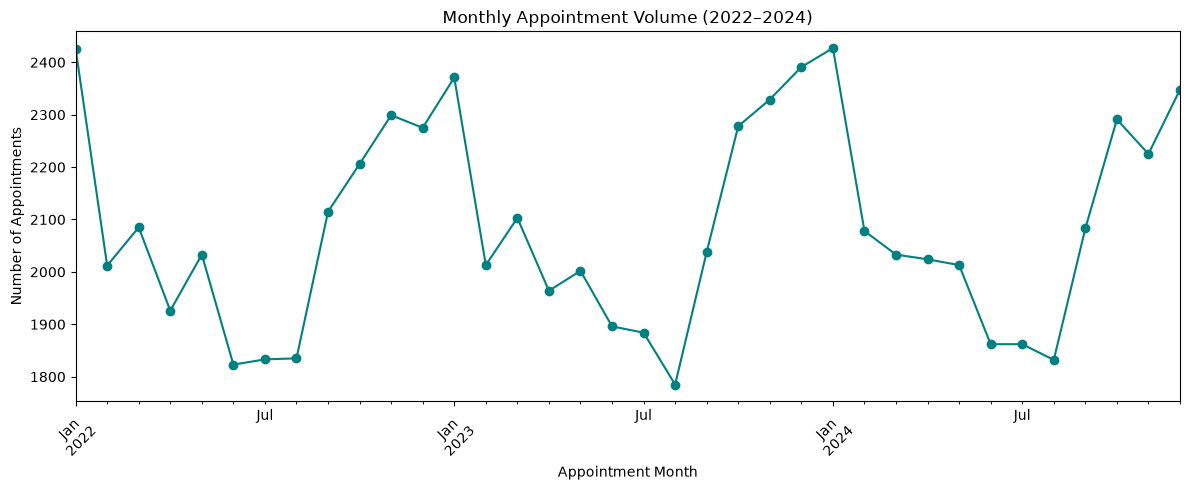

In [16]:
monthly_volume.plot(
    kind="line",
    figsize=(12, 5),
    marker="o",
    color="teal"
)

plt.title("Monthly Appointment Volume (2022–2024)")
plt.xlabel("Appointment Month")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight

January 2024 has the highest appointment volume (2,427), while
August 2023 has the lowest (1,785). The monthly pattern shows
recurring peaks around December–January and lower volumes
during the middle of the year.

In [17]:
print("Highest-volume month:",
      monthly_volume.idxmax(),
      "| Appointments:", monthly_volume.max())

print("Lowest-volume month:",
      monthly_volume.idxmin(),
      "| Appointments:", monthly_volume.min())

Highest-volume month: 2024-01 | Appointments: 2427
Lowest-volume month: 2023-08 | Appointments: 1785


### Quarterly Appointment Volume

,appointment_count
appointment_date,
2022Q1,6523
2022Q2,5782
2022Q3,5783
2022Q4,6780
2023Q1,6487
2023Q2,5862
2023Q3,5707
2023Q4,6998
2024Q1,6538


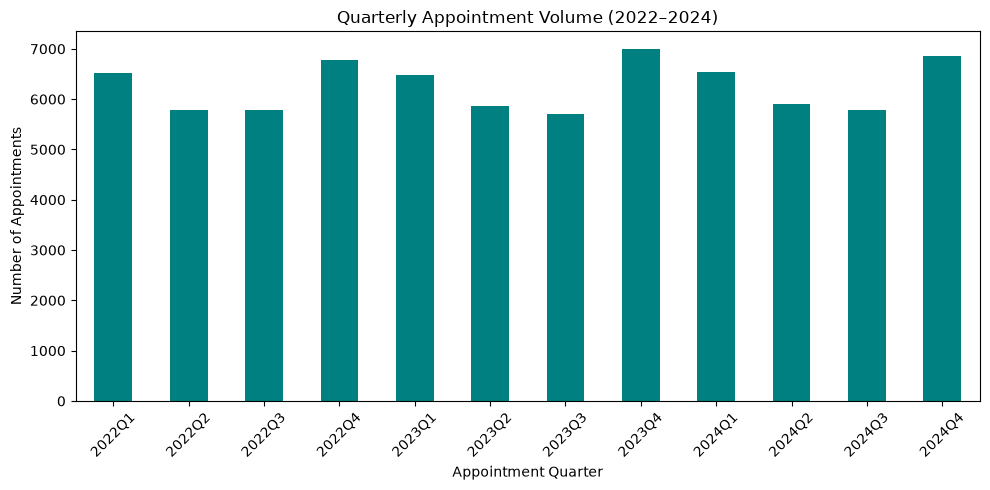

Highest-volume quarter: 2023Q4 | Appointments: 6998
Lowest-volume quarter: 2023Q3 | Appointments: 5707


In [18]:
quarterly_volume = (
    df.groupby(df["appointment_date"].dt.to_period("Q"))
    .size()
)

display(quarterly_volume.to_frame(name="appointment_count"))

quarterly_volume.plot(
    kind="bar",
    figsize=(10, 5),
    color="teal"
)

plt.title("Quarterly Appointment Volume (2022–2024)")
plt.xlabel("Appointment Quarter")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Highest-volume quarter:",
      quarterly_volume.idxmax(),
      "| Appointments:", quarterly_volume.max())

print("Lowest-volume quarter:",
      quarterly_volume.idxmin(),
      "| Appointments:", quarterly_volume.min())

### Insight

Q4 has the highest appointment volume in each year from 2022
to 2024. The busiest quarter is 2023 Q4 (6,998 appointments),
while the quietest is 2023 Q3 (5,707).

Apollo can use this recurring seasonal pattern to inform
staffing and appointment-capacity planning.

## What is the split of outcomes across completed, no-show, cancelled, and scheduled appointments?

,appointment_count,percentage
appointment_status,,
Completed,55275,73.70
No-Show,11584,15.45
Cancelled,5793,7.72
Scheduled,2348,3.13


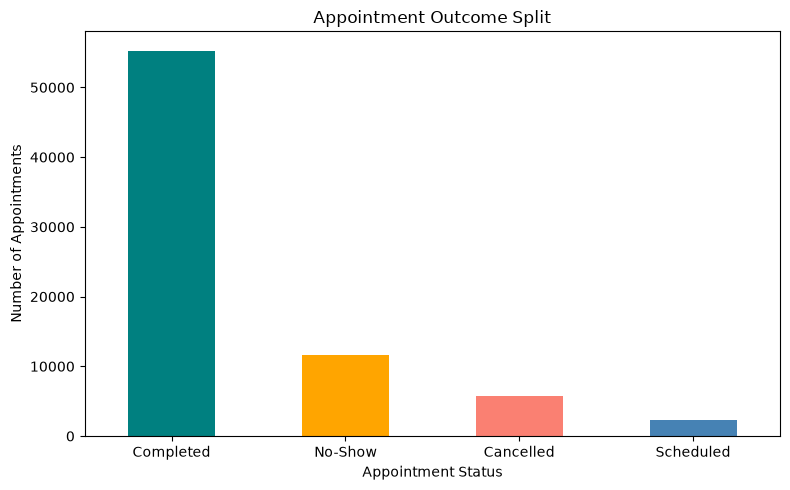

In [19]:
outcome_summary = (
    df["appointment_status"]
    .value_counts()
    .to_frame(name="appointment_count")
)

outcome_summary["percentage"] = (
    outcome_summary["appointment_count"] / len(df) * 100
).round(2)

display(outcome_summary)

outcome_summary["appointment_count"].plot(
    kind="bar",
    figsize=(8, 5),
    color=["teal", "orange", "salmon", "steelblue"]
)

plt.title("Appointment Outcome Split")
plt.xlabel("Appointment Status")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Insight

Of 75,000 appointments, 73.70% were Completed, 15.45% were
No-Show, 7.72% were Cancelled and 3.13% were Scheduled.

No-shows and cancellations together represent 23.17% of all
bookings. The separate no-show-rate metric is 15.94%, because
it excludes Scheduled appointments from its denominator.

## Which booking channels drive the highest volume, and how does the channel mix look?

,appointment_count,percentage
booking_channel,,
Apollo App,34042,45.39
Website,18545,24.73
Call Centre,11201,14.93
Walk-In,7501,10.00
Partner App,3711,4.95


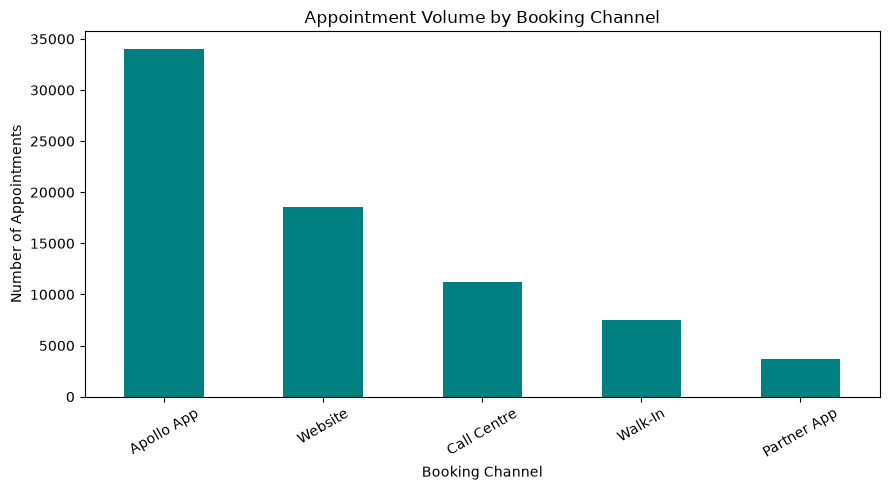

In [20]:
channel_summary = (
    df["booking_channel"]
    .value_counts()
    .to_frame(name="appointment_count")
)

channel_summary["percentage"] = (
    channel_summary["appointment_count"] / len(df) * 100
).round(2)

display(channel_summary)

channel_summary["appointment_count"].plot(
    kind="bar",
    figsize=(9, 5),
    color="teal"
)

plt.title("Appointment Volume by Booking Channel")
plt.xlabel("Booking Channel")
plt.ylabel("Number of Appointments")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

### Insight

Apollo App generates the most bookings (34,042; 45.39%),
followed by Website (18,545; 24.73%). Together, these channels
account for 70.12% of appointments.

Partner App contributes the smallest share (4.95%). Apollo
App and Website are therefore important channels for reaching
patients with booking guidance and reminders.

# No-Show Analysis

## Which specialties and cities have the highest and lowest no-show rates?

### No-Show Rate by Specialty

,eligible_appointments,no_show_count,no_show_rate
specialty,,,
Psychiatry,2900,711,24.52
Dermatology,7566,1608,21.25
ENT,5211,988,18.96
Endocrinology,2024,355,17.54
Ophthalmology,3103,503,16.21
General Physician,19654,3049,15.51
Pulmonology,2549,394,15.46
Orthopaedics,5419,810,14.95
Gastroenterology,2527,377,14.92


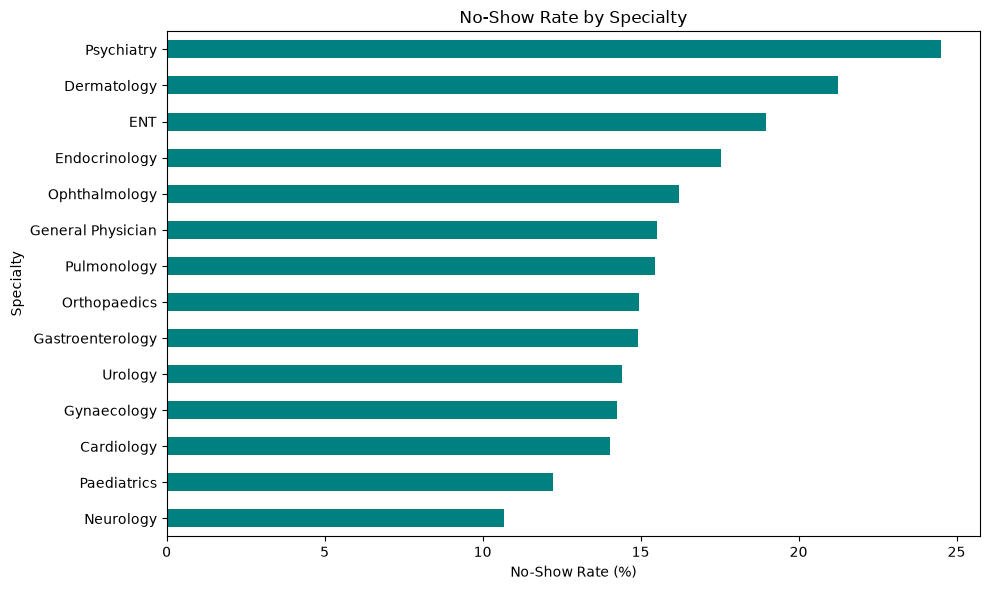

In [21]:
specialty_no_show = (
    eligible.groupby("specialty")
    .agg(
        eligible_appointments=("is_no_show", "size"),
        no_show_count=("is_no_show", "sum")
    )
)

specialty_no_show["no_show_rate"] = (
    specialty_no_show["no_show_count"]
    / specialty_no_show["eligible_appointments"] * 100
)

specialty_no_show = specialty_no_show.sort_values(
    "no_show_rate",
    ascending=False
)

display(specialty_no_show.round(2))

specialty_no_show["no_show_rate"].sort_values().plot(
    kind="barh",
    figsize=(10, 6),
    color="teal"
)

plt.title("No-Show Rate by Specialty")
plt.xlabel("No-Show Rate (%)")
plt.ylabel("Specialty")
plt.tight_layout()
plt.show()

### Insight

Psychiatry has the highest no-show rate (24.52%), followed by
Dermatology (21.25%). Neurology has the lowest rate (10.69%).

General Physician has the largest absolute number of no-shows
(3,049), despite a lower rate of 15.51%. Attendance-improvement
trials should consider both high rates and high missed volumes.

### No-Show Rate by City

,eligible_appointments,no_show_count,no_show_rate
city,,,
Lucknow,3001,516,17.19
Mumbai,9734,1659,17.04
Delhi,10404,1754,16.86
Bhopal,2001,336,16.79
Kolkata,5701,933,16.37
Kochi,2690,438,16.28
Ahmedabad,3468,561,16.18
Jaipur,2653,429,16.17
Hyderabad,7229,1160,16.05


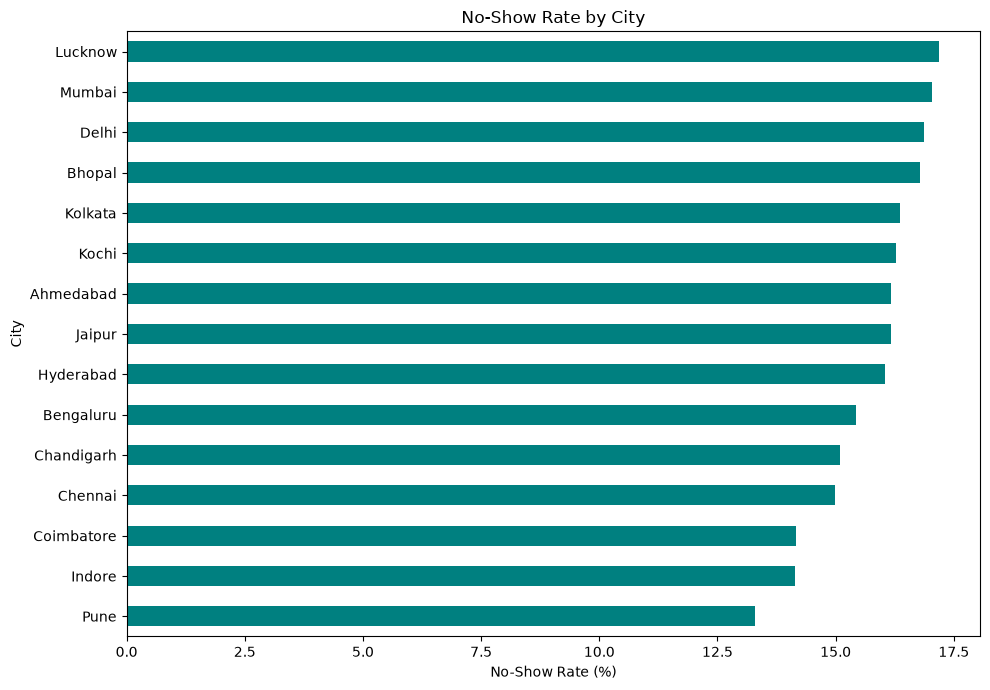

In [22]:
city_no_show = (
    eligible.groupby("city")
    .agg(
        eligible_appointments=("is_no_show", "size"),
        no_show_count=("is_no_show", "sum")
    )
)

city_no_show["no_show_rate"] = (
    city_no_show["no_show_count"]
    / city_no_show["eligible_appointments"] * 100
)

city_no_show = city_no_show.sort_values(
    "no_show_rate", ascending=False
)

display(city_no_show.round(2))

city_no_show["no_show_rate"].sort_values().plot(
    kind="barh",
    figsize=(10, 7),
    color="teal"
)

plt.title("No-Show Rate by City")
plt.xlabel("No-Show Rate (%)")
plt.ylabel("City")
plt.tight_layout()
plt.show()

### Insight

Lucknow has the highest no-show rate (17.19%), followed by
Mumbai (17.04%). Pune has the lowest rate (13.30%).

The highest-to-lowest gap is 3.89 percentage points. Apollo
should examine differences in booking channels, specialties
and patient mix before attributing this gap to location alone.

## How does booking lead time affect the probability of a no-show?

,eligible_appointments,no_show_count,no_show_rate
lead_time_group,,,
Same day,20180,3193,15.82
1–3 days,25475,3651,14.33
4–7 days,15897,2623,16.50
8–14 days,8758,1648,18.82
15–30 days,2342,469,20.03


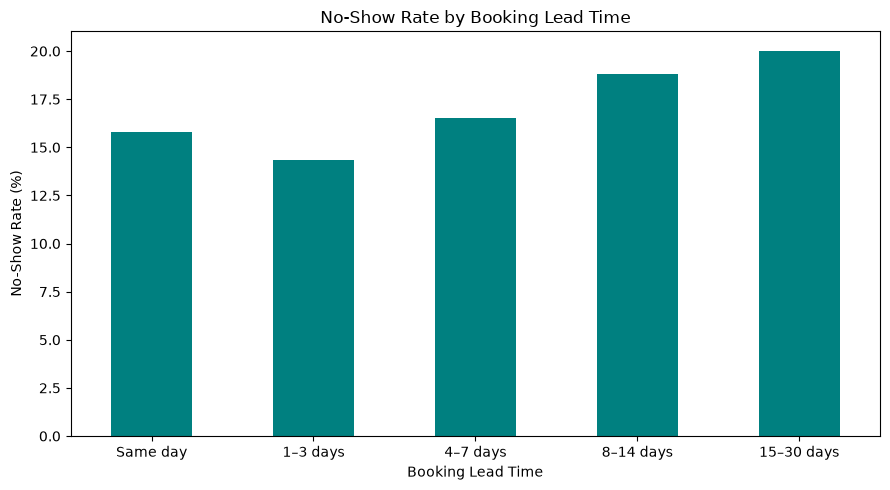

In [23]:
eligible["lead_time_group"] = pd.cut(
    eligible["booking_lead_days"],
    bins=[-1, 0, 3, 7, 14, 30],
    labels=["Same day", "1–3 days", "4–7 days",
            "8–14 days", "15–30 days"]
)

lead_time_summary = (
    eligible.groupby("lead_time_group", observed=True)
    .agg(
        eligible_appointments=("is_no_show", "size"),
        no_show_count=("is_no_show", "sum")
    )
)

lead_time_summary["no_show_rate"] = (
    lead_time_summary["no_show_count"]
    / lead_time_summary["eligible_appointments"] * 100
)

display(lead_time_summary.round(2))

lead_time_summary["no_show_rate"].plot(
    kind="bar",
    figsize=(9, 5),
    color="teal"
)

plt.title("No-Show Rate by Booking Lead Time")
plt.xlabel("Booking Lead Time")
plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Insight

Bookings made 1–3 days ahead have the lowest no-show rate
(14.33%). Rates increase across longer lead-time groups,
reaching 20.03% for bookings made 15–30 days ahead.

Same-day bookings have a rate of 15.82%, so the relationship
is not consistently increasing across every group. Apollo
could test extra reconfirmation for bookings made over a
week in advance.

## Do evening slots, weekends, and longer-lead bookings see higher dropout?

### No-Show Rate by Time of Day

,eligible_appointments,no_show_count,no_show_rate
time_of_day,,,
Afternoon,23231,4124,17.75
Evening,14553,2673,18.37
Morning,34868,4787,13.73


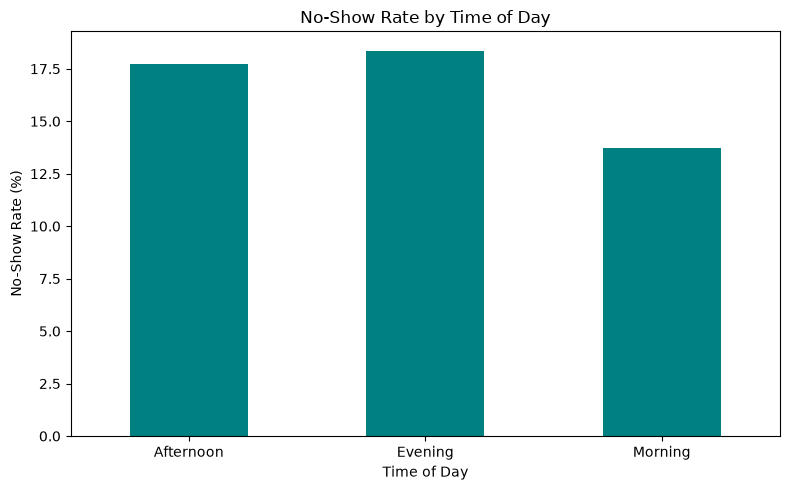

In [24]:
time_summary = (
    eligible.groupby("time_of_day")
    .agg(
        eligible_appointments=("is_no_show", "size"),
        no_show_count=("is_no_show", "sum")
    )
)

time_summary["no_show_rate"] = (
    time_summary["no_show_count"]
    / time_summary["eligible_appointments"] * 100
)

display(time_summary.round(2))

time_summary["no_show_rate"].plot(
    kind="bar",
    figsize=(8, 5),
    color="teal"
)

plt.title("No-Show Rate by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Insight

Evening appointments have the highest no-show rate (18.37%),
followed by Afternoon (17.75%) and Morning (13.73%).

Evening attendance is 4.64 percentage points worse than
Morning attendance. Apollo could test slot-specific reminders
and easier rescheduling for later appointments.

### Weekday vs Weekend No-Show Rate

,eligible_appointments,no_show_count,no_show_rate
day_type,,,
Weekday,51731,7676,14.84
Weekend,20921,3908,18.68


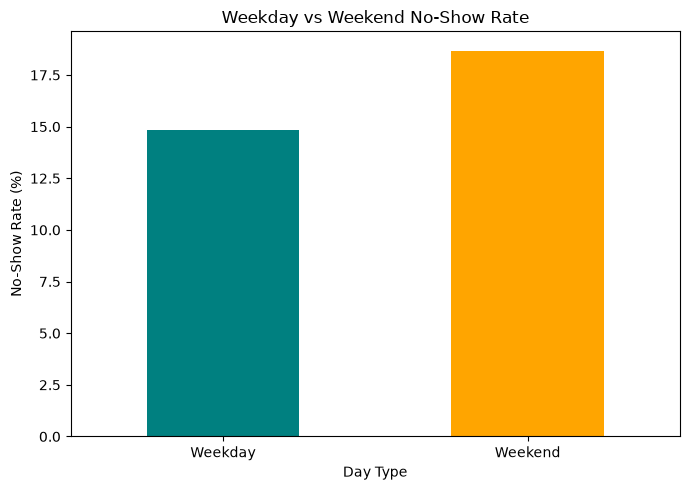

In [25]:
eligible["day_type"] = np.where(
    eligible["appointment_date"].dt.dayofweek >= 5,
    "Weekend",
    "Weekday"
)

weekend_summary = (
    eligible.groupby("day_type")
    .agg(
        eligible_appointments=("is_no_show", "size"),
        no_show_count=("is_no_show", "sum")
    )
)

weekend_summary["no_show_rate"] = (
    weekend_summary["no_show_count"]
    / weekend_summary["eligible_appointments"] * 100
)

display(weekend_summary.round(2))

weekend_summary["no_show_rate"].plot(
    kind="bar",
    figsize=(7, 5),
    color=["teal", "orange"]
)

plt.title("Weekday vs Weekend No-Show Rate")
plt.xlabel("Day Type")
plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Insight

Weekend appointments have a higher no-show rate (18.68%)
than weekday appointments (14.84%), a difference of 3.84
percentage points.

Together with the lead-time results, this identifies weekends
and longer-lead bookings as useful groups for reconfirmation
trials. These comparisons describe associations, not causes.

## Which appointment types and booking channels carry the most no-show risk?

### No-Show Rate by Appointment Type

,eligible_appointments,no_show_count,no_show_rate
appointment_type,,,
Home Visit,9742,2557,26.25
Video Consult,15349,3232,21.06
In-Clinic,47561,5795,12.18


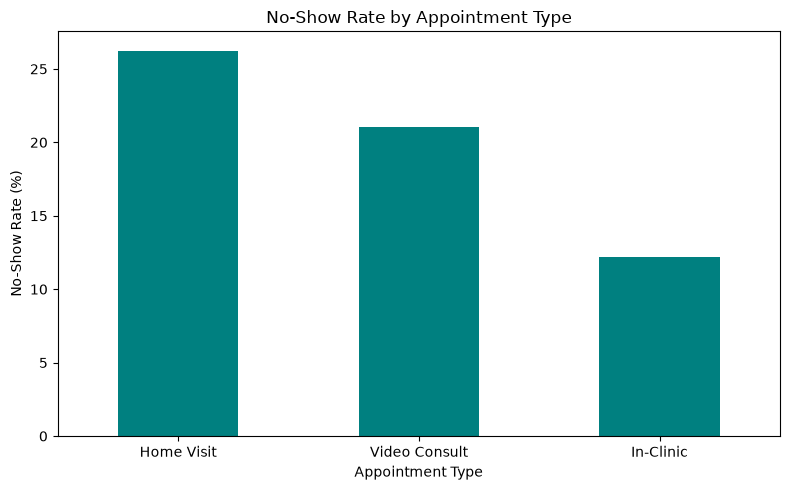

In [26]:
type_summary = (
    eligible.groupby("appointment_type")
    .agg(
        eligible_appointments=("is_no_show", "size"),
        no_show_count=("is_no_show", "sum")
    )
)

type_summary["no_show_rate"] = (
    type_summary["no_show_count"]
    / type_summary["eligible_appointments"] * 100
)

type_summary = type_summary.sort_values(
    "no_show_rate", ascending=False
)

display(type_summary.round(2))

type_summary["no_show_rate"].plot(
    kind="bar",
    figsize=(8, 5),
    color="teal"
)

plt.title("No-Show Rate by Appointment Type")
plt.xlabel("Appointment Type")
plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Insight

Home Visits have the highest no-show rate (26.25%), followed
by Video Consults (21.06%). In-Clinic appointments have the
lowest rate (12.18%).

Apollo could test additional confirmation for Home Visits
and clearer joining instructions for Video Consults.

### No-Show Rate by Booking Channel

,eligible_appointments,no_show_count,no_show_rate
booking_channel,,,
Walk-In,7281,1520,20.88
Partner App,3594,651,18.11
Website,17964,3090,17.20
Call Centre,10855,1650,15.20
Apollo App,32958,4673,14.18


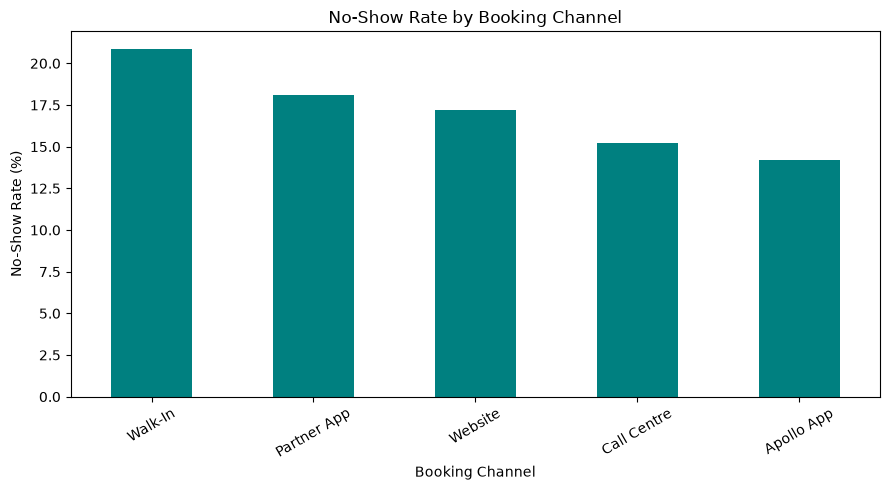

In [27]:
channel_risk = eligible.groupby("booking_channel").agg(
    eligible_appointments=("is_no_show", "size"),
    no_show_count=("is_no_show", "sum")
)

channel_risk["no_show_rate"] = (
    channel_risk["no_show_count"]
    / channel_risk["eligible_appointments"] * 100
)

channel_risk = channel_risk.sort_values(
    "no_show_rate", ascending=False
)

display(channel_risk.round(2))

channel_risk["no_show_rate"].plot(
    kind="bar", figsize=(9, 5), color="teal"
)

plt.title("No-Show Rate by Booking Channel")
plt.xlabel("Booking Channel")
plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=30)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

### Insight

Walk-In has the highest recorded no-show rate (20.88%),
followed by Partner App (18.11%). Apollo App has the lowest
rate (14.18%).

The meaning and recording of Walk-In no-shows should be
checked before acting on this result. Booking-channel
comparisons may also reflect differences in patient mix.

# Reminder and Engagement Effectiveness

## How much does reminder type reduce no-show rates compared to no-reminder patients?

,eligible_appointments,no_show_count,no_show_rate
reminder_type,,,
No Reminder,10977,3311,30.16
SMS Only,14527,2363,16.27
SMS + WhatsApp,25273,3414,13.51
SMS + WhatsApp + Call,21875,2496,11.41


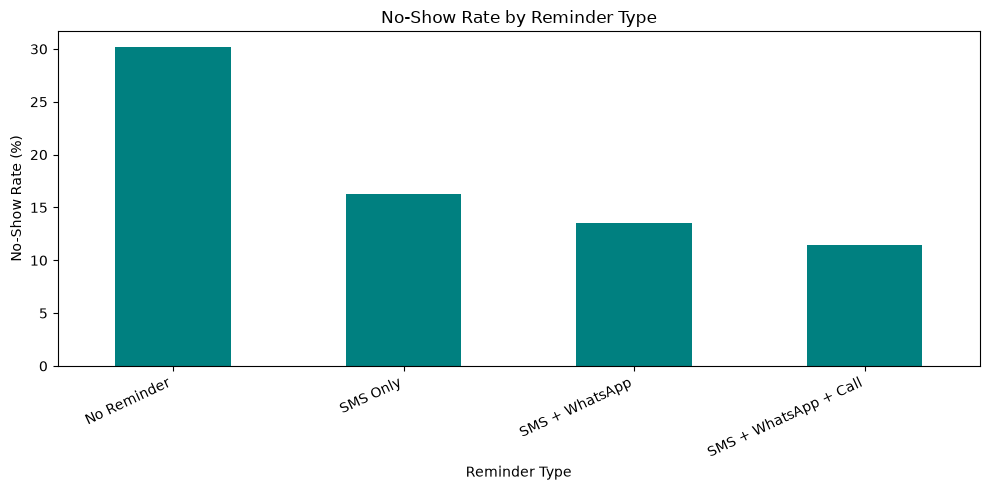

In [28]:
reminder_summary = eligible.groupby("reminder_type").agg(
    eligible_appointments=("is_no_show", "size"),
    no_show_count=("is_no_show", "sum")
)

reminder_summary["no_show_rate"] = (
    reminder_summary["no_show_count"]
    / reminder_summary["eligible_appointments"] * 100
)

reminder_summary = reminder_summary.sort_values(
    "no_show_rate", ascending=False
)

display(reminder_summary.round(2))

reminder_summary["no_show_rate"].plot(
    kind="bar", figsize=(10, 5), color="teal"
)

plt.title("No-Show Rate by Reminder Type")
plt.xlabel("Reminder Type")
plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=25, ha="right")
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

### Insight

Appointments with no reminder have a no-show rate of 30.16%.
Rates are lower for SMS Only (16.27%), SMS + WhatsApp (13.51%)
and SMS + WhatsApp + Call (11.41%).

The combined-reminder group has a rate 18.75 percentage points
below the no-reminder group. This supports testing combined
reminders, but the comparison does not establish a causal
reduction because reminder allocation may differ by patient.

## Does prior no-show history predict future no-show behaviour?

,eligible_appointments,no_show_count,no_show_rate
history_group,,,
0,63014,9549,15.15
1,8502,1723,20.27
2,983,262,26.65
3+,153,50,32.68


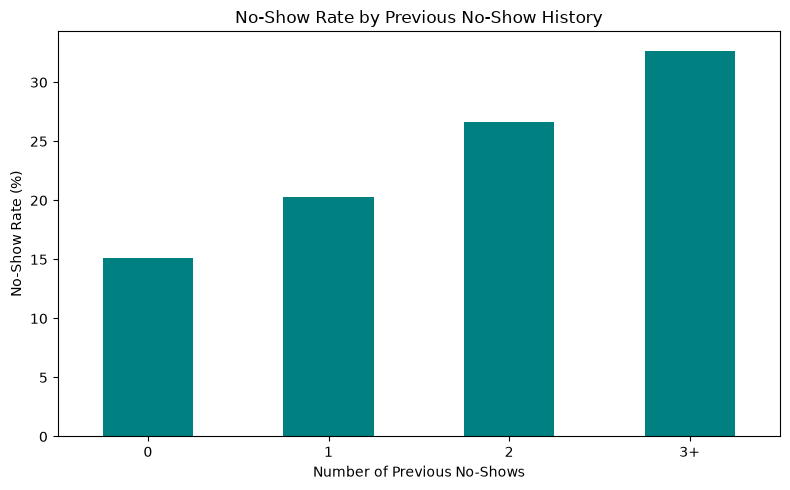

In [29]:
eligible["history_group"] = pd.cut(
    eligible["patient_prior_no_shows"],
    bins=[-1, 0, 1, 2, float("inf")],
    labels=["0", "1", "2", "3+"]
)

history_summary = eligible.groupby(
    "history_group", observed=True
).agg(
    eligible_appointments=("is_no_show", "size"),
    no_show_count=("is_no_show", "sum")
)

history_summary["no_show_rate"] = (
    history_summary["no_show_count"]
    / history_summary["eligible_appointments"] * 100
)

display(history_summary.round(2))

history_summary["no_show_rate"].plot(
    kind="bar", figsize=(8, 5), color="teal"
)

plt.title("No-Show Rate by Previous No-Show History")
plt.xlabel("Number of Previous No-Shows")
plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=0)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

### Insight

No-show rates increase with previous no-show history:
15.15% for no prior no-shows, 20.27% for one, 26.65% for two
and 32.68% for three or more.

Prior history can help identify patients for additional
reminders and reconfirmation. The three-or-more group contains
only 153 appointments, so its estimate is less stable.

## Do Apollo members and repeat patients show better attendance than non-members and first-time patients?

### Apollo Members vs Non-Members

,eligible_appointments,no_show_count,no_show_rate
apollo_member,,,
No,56428,9530,16.89
Yes,16224,2054,12.66


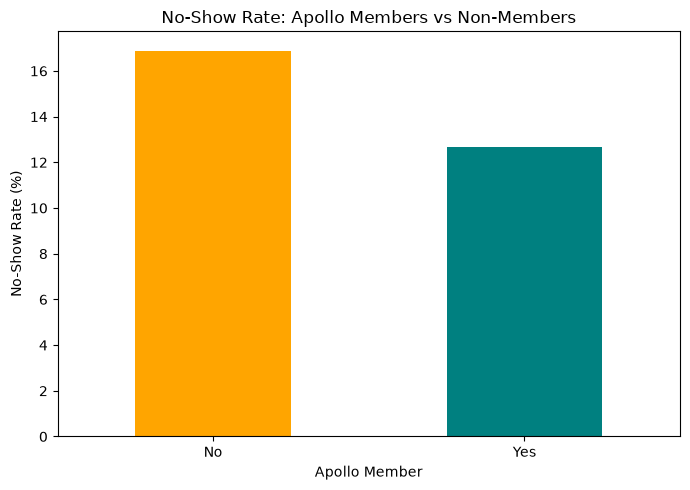

In [30]:
member_summary = eligible.groupby("apollo_member").agg(
    eligible_appointments=("is_no_show", "size"),
    no_show_count=("is_no_show", "sum")
)

member_summary["no_show_rate"] = (
    member_summary["no_show_count"]
    / member_summary["eligible_appointments"] * 100
)

display(member_summary.round(2))

member_summary["no_show_rate"].plot(
    kind="bar", figsize=(7, 5), color=["orange", "teal"]
)

plt.title("No-Show Rate: Apollo Members vs Non-Members")
plt.xlabel("Apollo Member")
plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=0)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

### Insight

Apollo members have a lower no-show rate (12.66%) than
non-members (16.89%), a difference of 4.23 percentage points.

Membership is associated with better attendance, although
this comparison does not prove that membership causes it.

,eligible_appointments,no_show_count,no_show_rate
patient_visit_group,,,
First-time patient,9182,6132,66.78
Returning patient,63470,5452,8.59


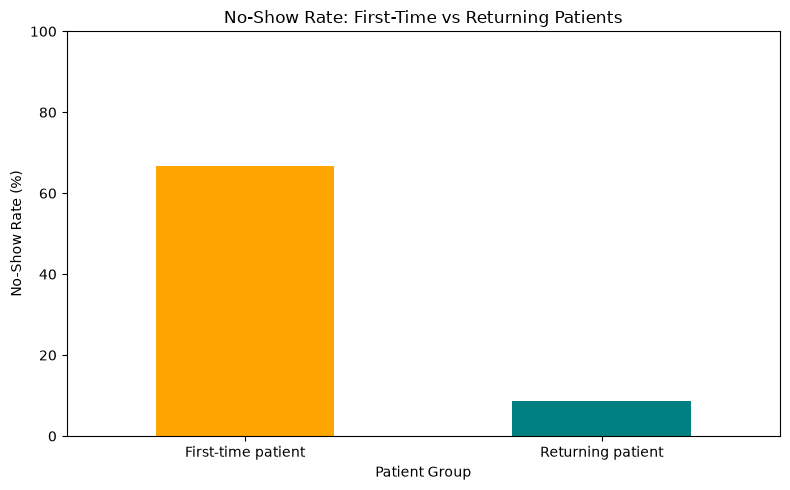

In [31]:
eligible["patient_visit_group"] = eligible["is_first_visit"].map(
    {0: "Returning patient", 1: "First-time patient"}
)

visit_summary = eligible.groupby("patient_visit_group").agg(
    eligible_appointments=("is_no_show", "size"),
    no_show_count=("is_no_show", "sum")
)

visit_summary["no_show_rate"] = (
    visit_summary["no_show_count"]
    / visit_summary["eligible_appointments"] * 100
)

display(visit_summary.round(2))

visit_summary["no_show_rate"].plot(
    kind="bar", figsize=(8, 5), color=["orange", "teal"]
)

plt.title("No-Show Rate: First-Time vs Returning Patients")
plt.xlabel("Patient Group")
plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=0)
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

### Insight

First-time patients have a much higher recorded no-show rate (66.78%) than returning patients (8.59%).

Apollo should test additional booking guidance and appointment reconfirmation for first-time patients. The unusually large difference warrants checking how first-time status is recorded before using it for operational decisions.

# Patient and Demographic Segmentation

## How do age group, gender, and chronic condition status influence no-show likelihood?

### No-Show Rate by Age Group

,eligible_appointments,no_show_count,no_show_rate
age_group,,,
Adult (31-45),15133,2731,18.05
Young Adult (19-30),10017,1797,17.94
Middle-aged (46-60),14862,2491,16.76
Teen (13-18),6379,939,14.72
Senior (60+),14516,2036,14.03
Child (0-12),11745,1590,13.54


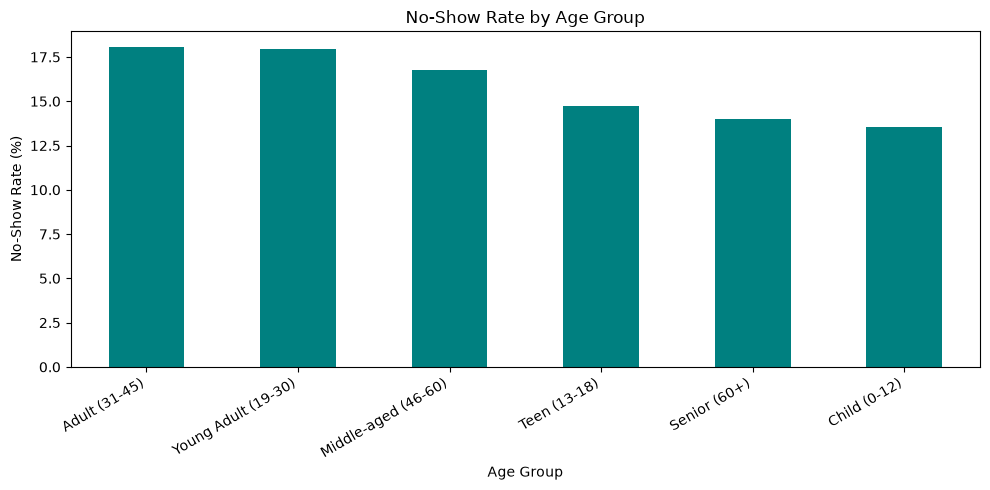

In [32]:
age_summary = eligible.groupby("age_group").agg(
    eligible_appointments=("is_no_show", "size"),
    no_show_count=("is_no_show", "sum")
)

age_summary["no_show_rate"] = (
    age_summary["no_show_count"]
    / age_summary["eligible_appointments"] * 100
)

age_summary = age_summary.sort_values(
    "no_show_rate", ascending=False
)

display(age_summary.round(2))

age_summary["no_show_rate"].plot(
    kind="bar", figsize=(10, 5), color="teal"
)

plt.title("No-Show Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=30, ha="right")
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

### Insight

Adults aged 31–45 have the highest no-show rate (18.05%),
closely followed by young adults aged 19–30 (17.94%).
Children have the lowest rate (13.54%).

Apollo could test additional reminders and easier rescheduling
for patients aged 19–45. These results show an association with
age group; they do not explain why appointments were missed.

### No-Show Rate by Gender

,eligible_appointments,no_show_count,no_show_rate
patient_gender,,,
Female,37589,6029,16.04
Male,35063,5555,15.84


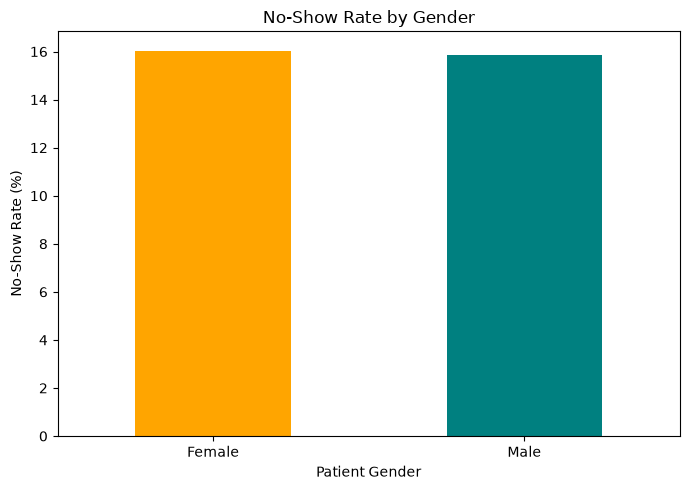

In [33]:
gender_summary = eligible.groupby("patient_gender").agg(
    eligible_appointments=("is_no_show", "size"),
    no_show_count=("is_no_show", "sum")
)

gender_summary["no_show_rate"] = (
    gender_summary["no_show_count"]
    / gender_summary["eligible_appointments"] * 100
)

gender_summary = gender_summary.sort_values(
    "no_show_rate", ascending=False
)

display(gender_summary.round(2))

gender_summary["no_show_rate"].plot(
    kind="bar", figsize=(7, 5), color=["orange", "teal"]
)

plt.title("No-Show Rate by Gender")
plt.xlabel("Patient Gender")
plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=0)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

### Insight

Female and male patients have similar no-show rates: 16.04% and
15.84%, respectively. The difference is only 0.20 percentage
points, so gender alone offers little practical separation of
no-show risk in this dataset. Apollo should prioritise stronger
observed factors, such as prior no-show history and booking
lead time, when testing engagement strategies.

### No-Show Rate by Chronic Condition Status

,eligible_appointments,no_show_count,no_show_rate
chronic_condition_status,,,
Has chronic condition,45508,7270,15.98
No chronic condition,27144,4314,15.89


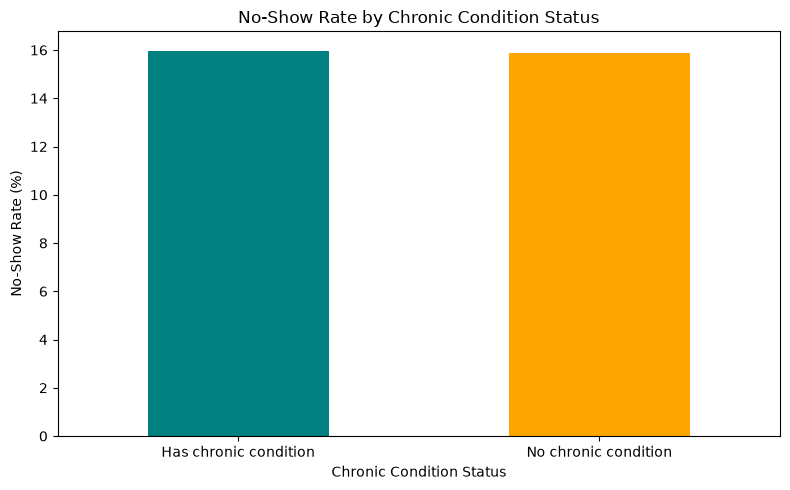

In [34]:
# "None" means no chronic condition; it is not a missing value.
eligible["chronic_condition_status"] = np.where(
    eligible["patient_chronic_condition"] == "None",
    "No chronic condition",
    "Has chronic condition"
)

chronic_summary = eligible.groupby("chronic_condition_status").agg(
    eligible_appointments=("is_no_show", "size"),
    no_show_count=("is_no_show", "sum")
)

chronic_summary["no_show_rate"] = (
    chronic_summary["no_show_count"]
    / chronic_summary["eligible_appointments"] * 100
)

display(chronic_summary.round(2))

chronic_summary["no_show_rate"].plot(
    kind="bar", figsize=(8, 5), color=["teal", "orange"]
)

plt.title("No-Show Rate by Chronic Condition Status")
plt.xlabel("Chronic Condition Status")
plt.ylabel("No-Show Rate (%)")
plt.xticks(rotation=0)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

### Insight

Patients with chronic conditions and those without have similar
no-show rates: 15.98% and 15.89%, respectively. The difference is
only 0.09 percentage points, so chronic condition status alone
provides little separation of no-show risk in this dataset.

## Which visit reasons are most common, and are some associated with higher dropout?

,total_appointments,eligible_appointments,no_show_count,no_show_rate
visit_reason,,,,
Follow-up,8807,8528,1298,15.22
Routine Checkup,8637,8377,1309,15.63
Chronic Condition Management,8380,8117,1266,15.60
Digestive Problem,8245,7984,1297,16.24
Fever & Infection,7041,6808,1095,16.08
Joint Pain,6664,6469,1082,16.73
Respiratory Issue,6590,6383,1020,15.98
Injury,6087,5884,949,16.13
Eye Care,2959,2869,444,15.48


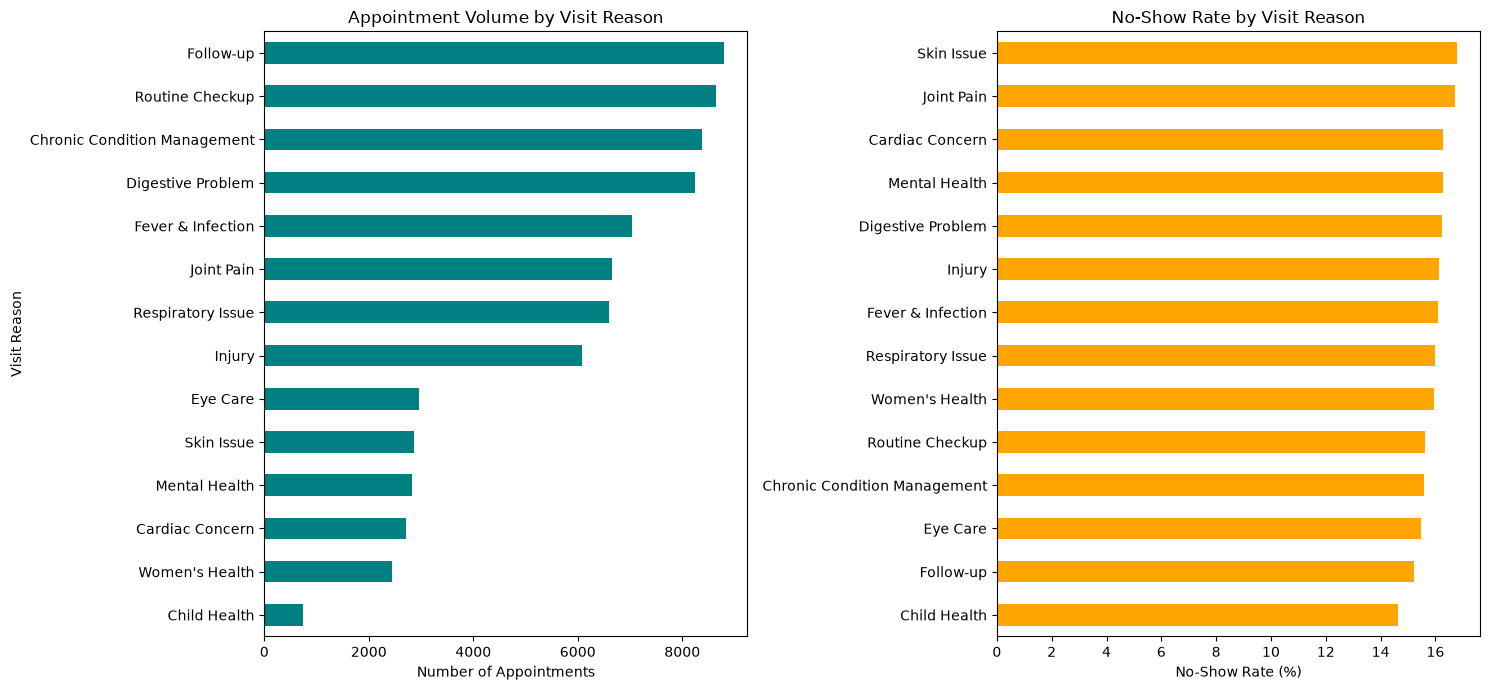

In [35]:
# Volume includes all appointments.
reason_volume = df["visit_reason"].value_counts().rename(
    "total_appointments"
)

# No-show rates exclude Scheduled appointments.
reason_summary = eligible.groupby("visit_reason").agg(
    eligible_appointments=("is_no_show", "size"),
    no_show_count=("is_no_show", "sum")
)

reason_summary = reason_summary.join(reason_volume)

reason_summary["no_show_rate"] = (
    reason_summary["no_show_count"]
    / reason_summary["eligible_appointments"] * 100
)

reason_summary = reason_summary.sort_values(
    "total_appointments", ascending=False
)

display(reason_summary[
    ["total_appointments", "eligible_appointments",
     "no_show_count", "no_show_rate"]
].round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

reason_summary["total_appointments"].sort_values().plot(
    kind="barh", ax=axes[0], color="teal"
)
axes[0].set_title("Appointment Volume by Visit Reason")
axes[0].set_xlabel("Number of Appointments")
axes[0].set_ylabel("Visit Reason")

reason_summary["no_show_rate"].sort_values().plot(
    kind="barh", ax=axes[1], color="orange"
)
axes[1].set_title("No-Show Rate by Visit Reason")
axes[1].set_xlabel("No-Show Rate (%)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### Insight

Follow-up is the most common visit reason, with 8,807 appointments,
followed by Routine Checkup (8,637) and Chronic Condition Management
(8,380).

Skin Issue has the highest no-show rate (16.79%), followed by
Joint Pain (16.73%). Child Health has the lowest rate (14.64%).
Rates vary by only 2.15 percentage points across visit reasons,
so visit reason alone provides limited separation of no-show risk.

These dropout comparisons use no-shows only; cancellations are
included in the denominator but are not counted as no-shows.

## What does the patient age distribution look like within Paediatrics, Gynaecology, and Psychiatry?

,appointment_count,mean_age,median_age,minimum_age,maximum_age
specialty,,,,,
Gynaecology,4113,41.69,42.0,1,85
Paediatrics,6382,9.25,9.0,1,18
Psychiatry,2989,41.96,42.0,1,85


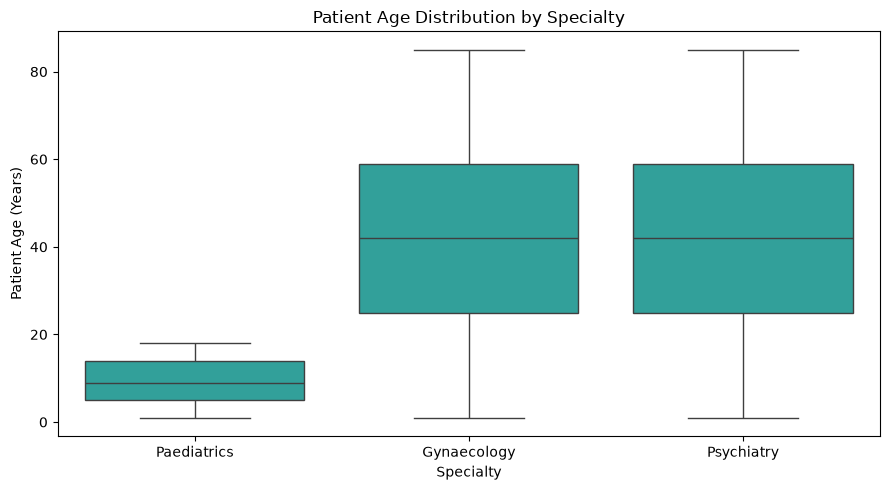

In [36]:
selected_specialties = [
    "Paediatrics", "Gynaecology", "Psychiatry"
]

specialty_age = df[
    df["specialty"].isin(selected_specialties)
].copy()

age_distribution = specialty_age.groupby("specialty").agg(
    appointment_count=("patient_age", "size"),
    mean_age=("patient_age", "mean"),
    median_age=("patient_age", "median"),
    minimum_age=("patient_age", "min"),
    maximum_age=("patient_age", "max")
)

display(age_distribution.round(2))

plt.figure(figsize=(9, 5))

sns.boxplot(
    data=specialty_age,
    x="specialty",
    y="patient_age",
    order=selected_specialties,
    color="lightseagreen"
)

plt.title("Patient Age Distribution by Specialty")
plt.xlabel("Specialty")
plt.ylabel("Patient Age (Years)")
plt.tight_layout()
plt.show()

### Insight

Paediatrics appointments involve patients aged 1–18, with a median
age of 9. Gynaecology and Psychiatry both have a median age of 42
and a broader recorded age range of 1–85.

The very young ages recorded in Gynaecology and Psychiatry warrant
checking the source records and specialty definitions before
drawing clinical conclusions.

This analysis includes all appointment statuses. Each appointment
contributes one age observation, so repeat patients may appear
multiple times; this is not a distribution of unique patients.

# Financial Performance

## How much revenue is being lost to no-shows?

In [37]:
no_show_appointments = df[
    df["appointment_status"] == "No-Show"
].copy()

potential_revenue_loss = (
    no_show_appointments["consultation_fee"].sum()
)

average_missed_fee = (
    no_show_appointments["consultation_fee"].mean()
)

print(f"No-show appointments: {len(no_show_appointments):,}")
print(f"Potential revenue at risk: ₹{potential_revenue_loss:,.2f}")
print(f"In lakh: ₹{potential_revenue_loss / 100000:,.2f} lakh")
print(f"Average listed fee per no-show: ₹{average_missed_fee:,.2f}")

No-show appointments: 11,584
Potential revenue at risk: ₹19,725,460.00
In lakh: ₹197.25 lakh
Average listed fee per no-show: ₹1,702.82


### Insight

The 11,584 no-show appointments represent ₹1.97 crore in potential
consultation revenue at listed fees. The average listed fee per
missed appointment is ₹1,702.82.

This estimate assumes every no-show would otherwise have completed
the consultation at the listed fee, with no replacement booking.
It does not account for discounts, insurance settlement, or later
rescheduling, so it represents potential revenue at risk rather
than confirmed net revenue lost.

## How does average revenue vary across specialties and appointment types?

,completed_appointments,average_revenue
specialty,,
Psychiatry,1958,2640.45
Neurology,3899,2076.48
Urology,1729,1988.62
Cardiology,3507,1940.77
Gastroenterology,1972,1896.82
Endocrinology,1504,1812.68
Pulmonology,1961,1803.23
Orthopaedics,4189,1547.20
Gynaecology,3134,1499.59


,completed_appointments,average_revenue
appointment_type,,
Home Visit,6436,1960.05
In-Clinic,37938,1299.83
Video Consult,10901,1097.70


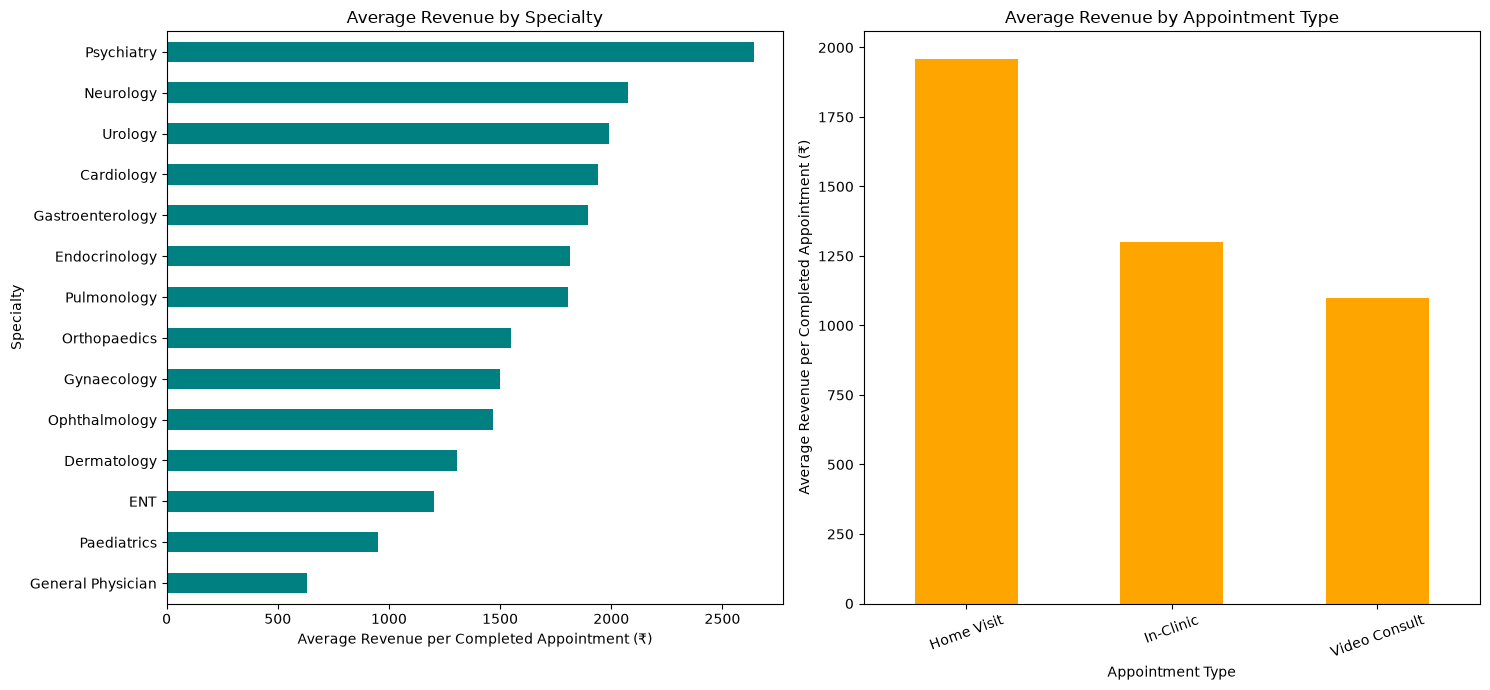

In [38]:
# Realized revenue analysis: Completed appointments only.
completed = df[
    df["appointment_status"] == "Completed"
].copy()

specialty_revenue = completed.groupby("specialty").agg(
    completed_appointments=("appointment_id", "size"),
    average_revenue=("revenue_realized", "mean")
).sort_values("average_revenue", ascending=False)

type_revenue = completed.groupby("appointment_type").agg(
    completed_appointments=("appointment_id", "size"),
    average_revenue=("revenue_realized", "mean")
).sort_values("average_revenue", ascending=False)

display(specialty_revenue.round(2))
display(type_revenue.round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

specialty_revenue["average_revenue"].sort_values().plot(
    kind="barh", ax=axes[0], color="teal"
)
axes[0].set_title("Average Revenue by Specialty")
axes[0].set_xlabel("Average Revenue per Completed Appointment (₹)")
axes[0].set_ylabel("Specialty")

type_revenue["average_revenue"].plot(
    kind="bar", ax=axes[1], color="orange"
)
axes[1].set_title("Average Revenue by Appointment Type")
axes[1].set_xlabel("Appointment Type")
axes[1].set_ylabel("Average Revenue per Completed Appointment (₹)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

### Insight

Psychiatry generates the highest average realized revenue per
completed appointment (₹2,640.45), while General Physician
generates the lowest (₹632.79).

Home Visits have the highest average revenue (₹1,960.05), followed
by In-Clinic consultations (₹1,299.83) and Video Consults
(₹1,097.70).

These averages use Completed appointments only. Higher revenue
per appointment does not necessarily mean higher profit, because
service costs are not included in this analysis.

## Which cities generate the most revenue, and what is the payment mode mix?

,total_revenue
city,
Bengaluru,9990616
Delhi,9958247
Mumbai,8989613
Hyderabad,7503245
Chennai,7188473
Kolkata,6543084
Pune,4734139
Ahmedabad,3956890
Lucknow,3177444


,completed_appointments,percentage
payment_mode,,
Insurance,11641,21.06
Debit Card,7353,13.30
Net Banking,7349,13.30
Apollo Pay,7324,13.25
UPI,7259,13.13
Credit Card,7213,13.05
Cash,7136,12.91


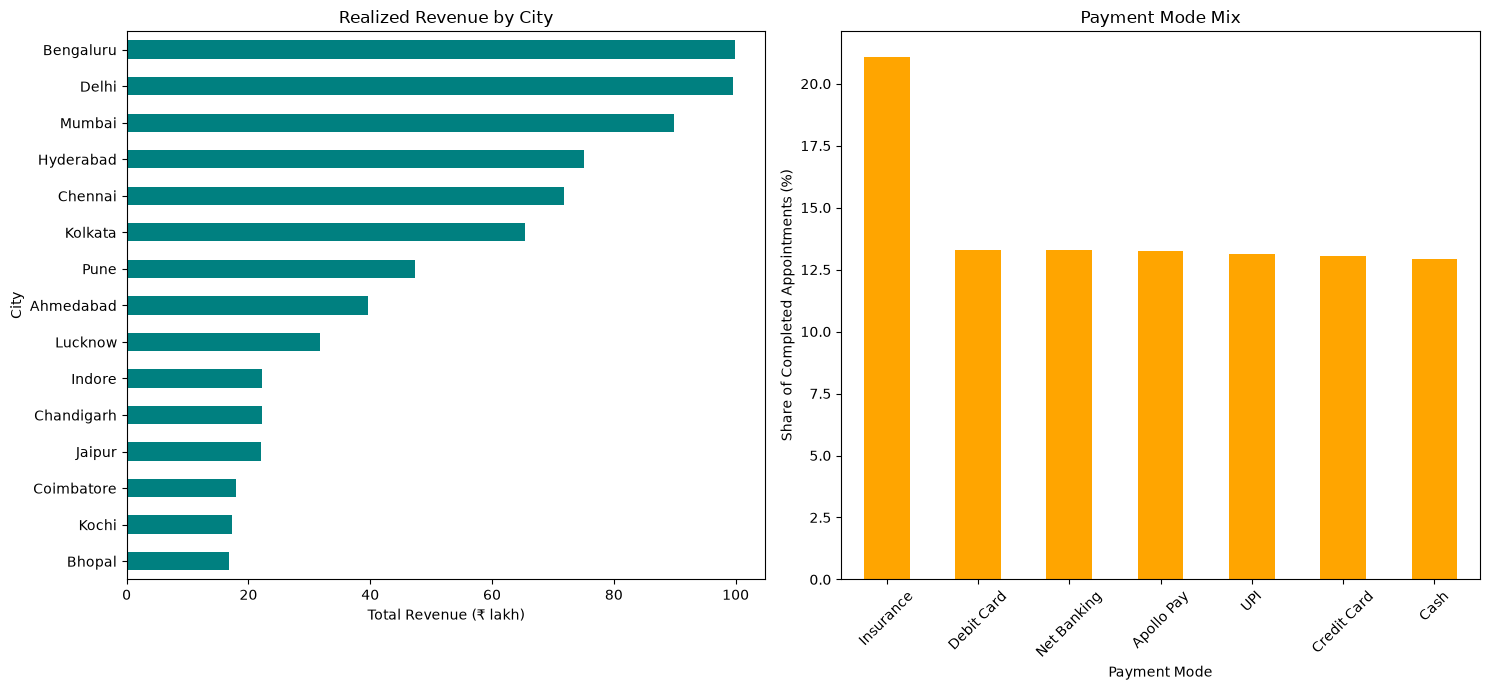

In [39]:
# Use Completed appointments only.
completed = df[df["appointment_status"] == "Completed"].copy()

city_revenue = (
    completed.groupby("city")["revenue_realized"]
    .sum()
    .sort_values(ascending=False)
    .to_frame("total_revenue")
)

payment_mix = (
    completed["payment_mode"]
    .value_counts()
    .to_frame("completed_appointments")
)

payment_mix["percentage"] = (
    payment_mix["completed_appointments"] / len(completed) * 100
)

display(city_revenue.round(2))
display(payment_mix.round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

(city_revenue["total_revenue"] / 100000).sort_values().plot(
    kind="barh", ax=axes[0], color="teal"
)
axes[0].set_title("Realized Revenue by City")
axes[0].set_xlabel("Total Revenue (₹ lakh)")
axes[0].set_ylabel("City")

payment_mix["percentage"].plot(
    kind="bar", ax=axes[1], color="orange"
)
axes[1].set_title("Payment Mode Mix")
axes[1].set_xlabel("Payment Mode")
axes[1].set_ylabel("Share of Completed Appointments (%)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### Insight

Bengaluru generates the most realized revenue (₹99.91 lakh),
closely followed by Delhi (₹99.58 lakh) and Mumbai (₹89.90 lakh).
Bhopal generates the least (₹16.84 lakh).

Insurance is the largest recorded payment mode, accounting for
21.06% of Completed appointments. Other payment modes each
account for approximately 13%.

The payment mix measures appointment counts, not revenue shares.
City revenue totals reflect both completed appointment volume
and revenue per appointment; they do not measure profitability.

## How does insurance coverage affect what patients pay out of pocket?

,completed_appointments,average_fee,average_insurer_payment,average_out_of_pocket
insurance_coverage,,,,
No,37523,1562.82,0.00,1562.82
Yes,17752,1556.35,697.17,859.18


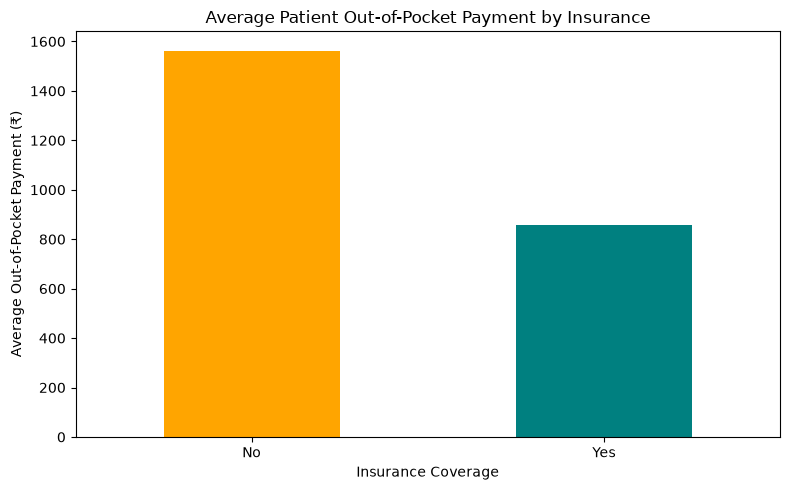

In [40]:
# Financial analysis uses Completed appointments only.
completed = df[df["appointment_status"] == "Completed"].copy()

insurance_summary = completed.groupby("insurance_coverage").agg(
    completed_appointments=("appointment_id", "size"),
    average_fee=("actual_fee_charged", "mean"),
    average_insurer_payment=("insurance_covered_amount", "mean"),
    average_out_of_pocket=("patient_out_of_pocket", "mean")
)

display(insurance_summary.round(2))

insurance_summary["average_out_of_pocket"].plot(
    kind="bar", figsize=(8, 5), color=["orange", "teal"]
)

plt.title("Average Patient Out-of-Pocket Payment by Insurance")
plt.xlabel("Insurance Coverage")
plt.ylabel("Average Out-of-Pocket Payment (₹)")
plt.xticks(rotation=0)
plt.ylim(bottom=0)
plt.tight_layout()
plt.show()

### Insight

Insured patients pay an average of ₹859.18 out of pocket per
completed appointment, compared with ₹1,562.82 for uninsured
patients—approximately 45% less.

Average fees are similar for both groups. Insurers contribute
an average of ₹697.17 per insured completed appointment,
reducing the amount paid directly by patients.

These comparisons use Completed appointments only and describe
the observed groups, without controlling for differences in
specialty or appointment type.

# Doctor Utilisation and Service Quality

## Which specialties have the highest and lowest doctor utilisation rates?

,completed_appointments,average_utilisation
specialty,,
Gastroenterology,1972,77.26
Endocrinology,1504,77.15
Cardiology,3507,76.81
Gynaecology,3134,76.80
Paediatrics,4900,76.66
Neurology,3899,76.63
General Physician,14981,76.59
Urology,1729,76.44
Orthopaedics,4189,76.43


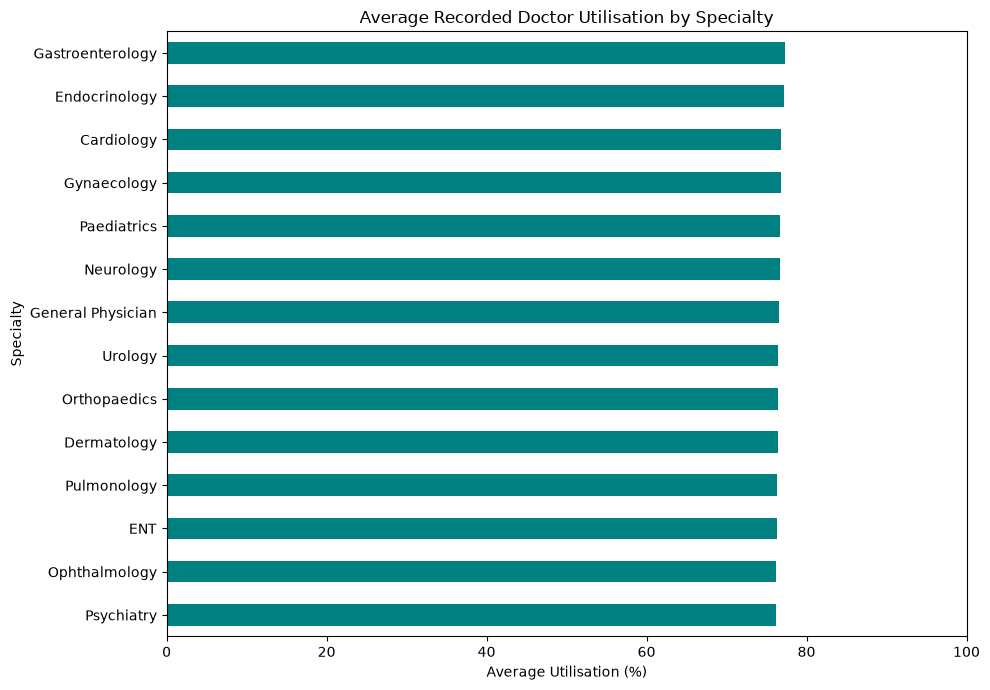

In [41]:
# Quality metrics: Completed appointments only.
completed = df[df["appointment_status"] == "Completed"].copy()

utilisation_summary = completed.groupby("specialty").agg(
    completed_appointments=("appointment_id", "size"),
    average_utilisation=("doctor_utilization_pct", "mean")
).sort_values("average_utilisation", ascending=False)

display(utilisation_summary.round(2))

utilisation_summary["average_utilisation"].sort_values().plot(
    kind="barh", figsize=(10, 7), color="teal"
)

plt.title("Average Recorded Doctor Utilisation by Specialty")
plt.xlabel("Average Utilisation (%)")
plt.ylabel("Specialty")
plt.xlim(0, 100)
plt.tight_layout()
plt.show()

### Insight

Gastroenterology has the highest average recorded utilisation
(77.26%), while Psychiatry has the lowest (76.18%). The gap is
only 1.08 percentage points, indicating similar recorded
utilisation across specialties.

This calculation averages utilisation values on Completed
appointment rows. It is an appointment-weighted average, not
a direct calculation of filled slots divided by available slots.
Doctors with more completed appointments contribute more
observations to the result.

## How long are patients waiting, and does it vary by specialty or time of day?

Overall average wait: 11.55 minutes


,average_wait_minutes,median_wait_minutes
specialty,,
Ophthalmology,12.02,8.0
Urology,11.91,8.0
Dermatology,11.77,8.0
Orthopaedics,11.70,8.0
Neurology,11.64,8.0
Gynaecology,11.62,8.0
Cardiology,11.59,8.0
General Physician,11.53,8.0
Endocrinology,11.46,8.0


,average_wait_minutes,median_wait_minutes
time_of_day,,
Morning,11.55,8.0
Afternoon,11.55,8.0
Evening,11.55,8.0


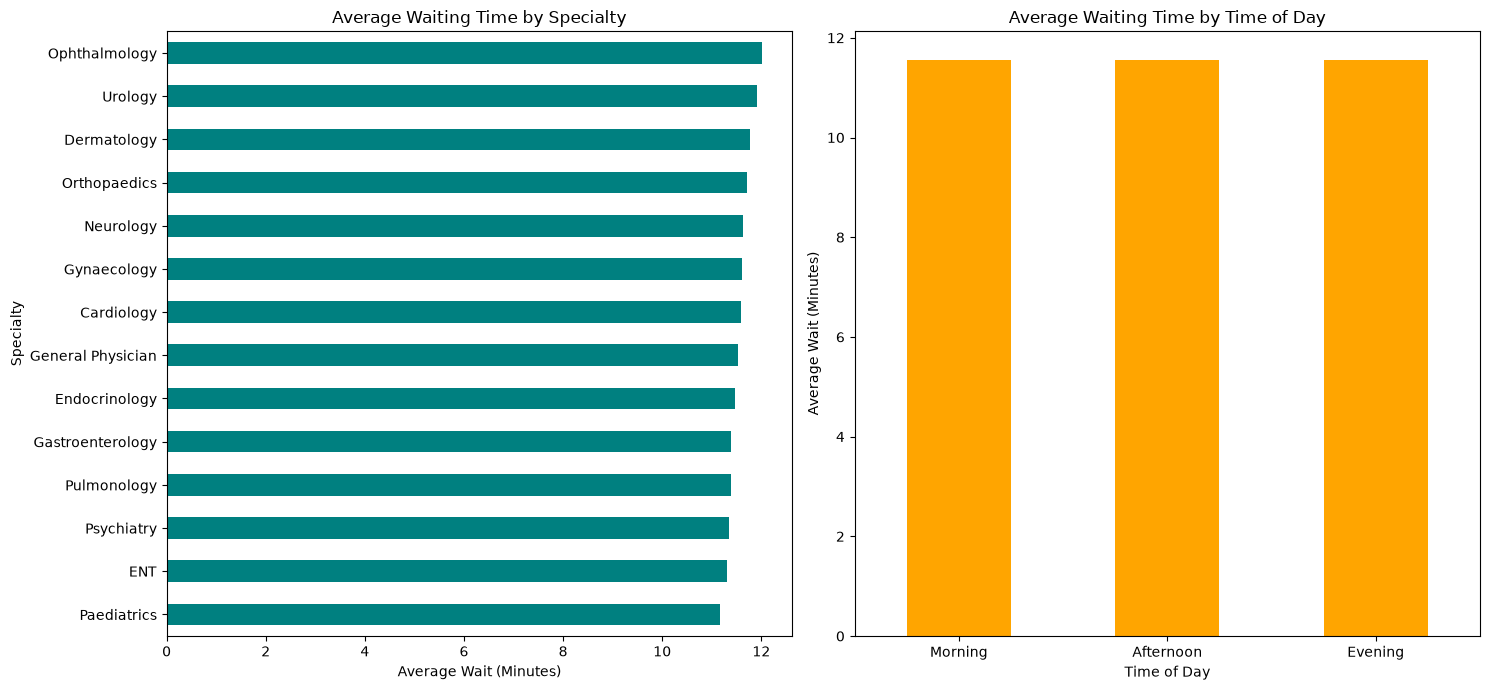

In [42]:
# Quality analysis: Completed appointments only.
completed = df[df["appointment_status"] == "Completed"].copy()

specialty_wait = completed.groupby("specialty").agg(
    average_wait_minutes=("wait_time_minutes", "mean"),
    median_wait_minutes=("wait_time_minutes", "median")
).sort_values("average_wait_minutes", ascending=False)

time_wait = completed.groupby("time_of_day").agg(
    average_wait_minutes=("wait_time_minutes", "mean"),
    median_wait_minutes=("wait_time_minutes", "median")
).reindex(["Morning", "Afternoon", "Evening"])

print(
    f"Overall average wait: "
    f"{completed['wait_time_minutes'].mean():.2f} minutes"
)

display(specialty_wait.round(2))
display(time_wait.round(2))

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

specialty_wait["average_wait_minutes"].sort_values().plot(
    kind="barh", ax=axes[0], color="teal"
)
axes[0].set_title("Average Waiting Time by Specialty")
axes[0].set_xlabel("Average Wait (Minutes)")
axes[0].set_ylabel("Specialty")

time_wait["average_wait_minutes"].plot(
    kind="bar", ax=axes[1], color="orange"
)
axes[1].set_title("Average Waiting Time by Time of Day")
axes[1].set_xlabel("Time of Day")
axes[1].set_ylabel("Average Wait (Minutes)")
axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show()

### Insight

Patients wait an average of 11.55 minutes for Completed
appointments. Ophthalmology has the longest average wait
(12.02 minutes), while Paediatrics has the shortest
(11.18 minutes)—a difference of only 0.84 minutes.

Morning, Afternoon and Evening average waits all round to
11.55 minutes, showing little variation by time of day.

Median waits are generally 8 minutes, below the overall mean.
This suggests longer waits for some appointments raise the
average; examining the longest waits would help identify
where service improvements are needed.

## Is there a relationship between consultation duration and patient satisfaction?

Completed appointments: 55,275
Pearson correlation: -0.0035


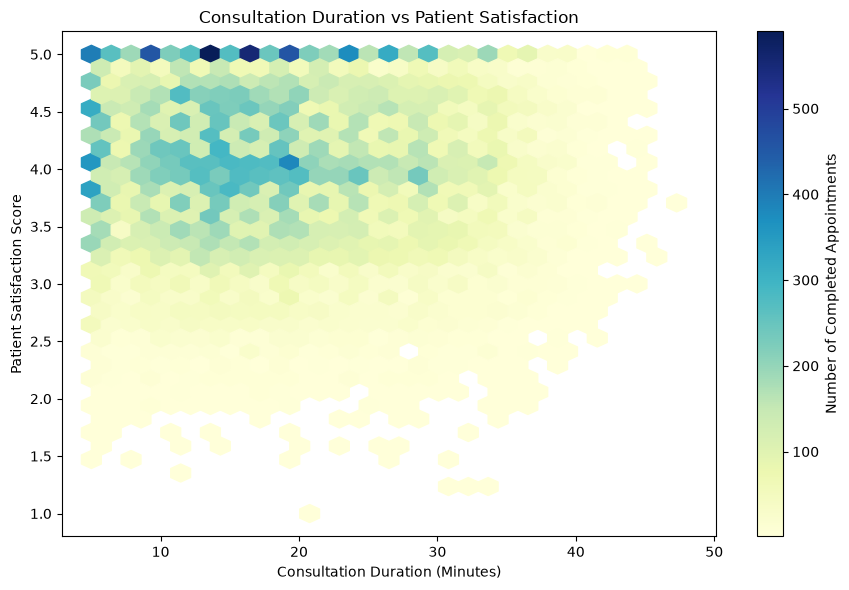

In [43]:
# Quality analysis: Completed appointments only.
completed = df[df["appointment_status"] == "Completed"].copy()

correlation = completed["consultation_duration_min"].corr(
    completed["patient_satisfaction_score"]
)

print(f"Completed appointments: {len(completed):,}")
print(f"Pearson correlation: {correlation:.4f}")

plt.figure(figsize=(9, 6))

plt.hexbin(
    completed["consultation_duration_min"],
    completed["patient_satisfaction_score"],
    gridsize=30,
    mincnt=1,
    cmap="YlGnBu"
)

plt.colorbar(label="Number of Completed Appointments")
plt.title("Consultation Duration vs Patient Satisfaction")
plt.xlabel("Consultation Duration (Minutes)")
plt.ylabel("Patient Satisfaction Score")
plt.tight_layout()
plt.show()

### Insight

Consultation duration and patient satisfaction have a Pearson
correlation of -0.0035, which is very close to zero. There is
no meaningful linear relationship between these measures
among Completed appointments in this dataset.

Longer consultations are not consistently associated with
higher satisfaction. Apollo should investigate other service
factors before changing consultation lengths to improve
satisfaction.

A near-zero correlation does not rule out nonlinear patterns
or relationships within individual specialties.

## How does doctor experience relate to the fee charged?

Doctors analysed: 320
Pearson correlation: 0.2780


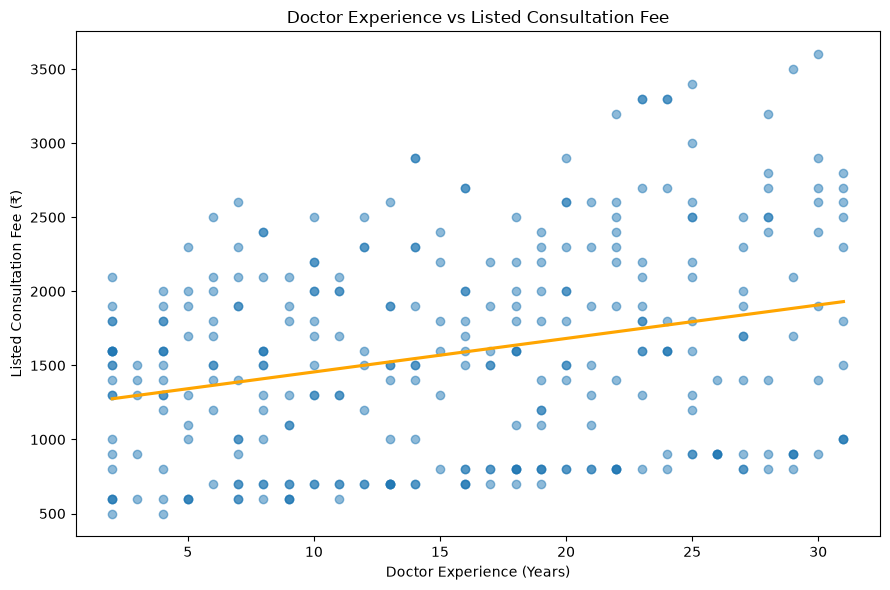

In [44]:
# Doctor attributes from our earlier doctor_id join.
doctor_fee_analysis = df[
    ["doctor_id", "experience_years", "consultation_fee_doctor"]
].drop_duplicates("doctor_id")

correlation = doctor_fee_analysis["experience_years"].corr(
    doctor_fee_analysis["consultation_fee_doctor"]
)

print(f"Doctors analysed: {len(doctor_fee_analysis):,}")
print(f"Pearson correlation: {correlation:.4f}")

plt.figure(figsize=(9, 6))

sns.regplot(
    data=doctor_fee_analysis,
    x="experience_years",
    y="consultation_fee_doctor",
    ci=None,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "orange"}
)

plt.title("Doctor Experience vs Listed Consultation Fee")
plt.xlabel("Doctor Experience (Years)")
plt.ylabel("Listed Consultation Fee (₹)")
plt.tight_layout()
plt.show()

### Insight

Doctor experience and listed consultation fees have a modest
positive correlation of 0.2780. More experienced doctors tend
to charge higher fees, but experience alone does not explain
the variation in fees.

Specialty and city may also influence pricing, so these should
be considered before attributing fee differences to experience.

Each doctor is counted once. This analysis uses listed doctor
fees rather than realized revenue or the amount patients pay
after discounts and insurance.

# Conclusions and Recommendations

## Key Findings

- Of 75,000 appointments, 55,275 were completed and 11,584
  resulted in no-shows. The no-show rate is 15.94%, excluding
  Scheduled appointments from the denominator.

- Appointment volume shows recurring seasonal patterns:
  Q4 has the highest volume in each year from 2022 to 2024.

- Psychiatry has the highest specialty no-show rate (24.52%),
  while Neurology has the lowest (10.69%).

- Weekend appointments have a higher no-show rate (18.68%)
  than weekday appointments (14.84%). Bookings made 15–30 days
  ahead have a no-show rate of 20.03%.

- Combined SMS, WhatsApp and call reminders are associated
  with an 11.41% no-show rate, compared with 30.16% for
  appointments with no reminder.

- Previous no-show history is associated with higher risk.
  First-time patients also have a much higher recorded
  no-show rate than returning patients.

- No-shows represent approximately ₹1.97 crore in potential
  revenue at listed consultation fees. This is an opportunity
  estimate, not confirmed net revenue lost.

- Bengaluru generates the most realized revenue. Home Visits
  generate the highest average revenue per completed appointment.

- Insured patients pay approximately 45% less out of pocket
  on average than uninsured patients.

- Recorded utilisation and average waiting times vary little
  across specialties. Consultation duration has almost no
  linear relationship with patient satisfaction.

## Recommended Actions

- Test additional reminders and reconfirmation for weekend
  appointments, longer-lead bookings and patients with
  previous no-shows.

- Prioritise Psychiatry and Dermatology for attendance
  improvement trials. Include General Physician because
  it has the largest absolute number of no-shows.

- Verify how first-time status is recorded, then test clearer
  booking guidance and onboarding for new patients.

- Make cancellation and rescheduling easier so unused slots
  can be offered to other patients.

- Investigate unusually long waits rather than relying only
  on average waiting times.

- Evaluate interventions through a controlled pilot, tracking
  no-show rates, cancellations, recovered appointments,
  realized revenue and intervention costs.

## Analysis Scope and Limitations

- No-show rates use Completed, No-Show and Cancelled
  appointments only; Scheduled appointments are excluded.

- Realized revenue and service-quality analyses use
  Completed appointments only.

- The literal value "None" means not applicable in the
  specified fields and is not treated as missing.

- Results describe associations and do not establish causation.

- Most comparisons use appointments rather than unique patients.

- Utilisation is an appointment-weighted average of the
  recorded metric, not a calculation from available-slot data.

- Potential revenue at risk does not account for replacement
  bookings, later rescheduling, discounts or insurance settlement.